In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

### 1. Overview of the Dataset

In [16]:
df = pd.read_csv('AmesHousing.csv')
print(df.shape)
print(df.columns)

(2930, 82)
Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr B

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

### 2. Feature Engineering of the target variable

<Axes: xlabel='SalePrice', ylabel='Density'>

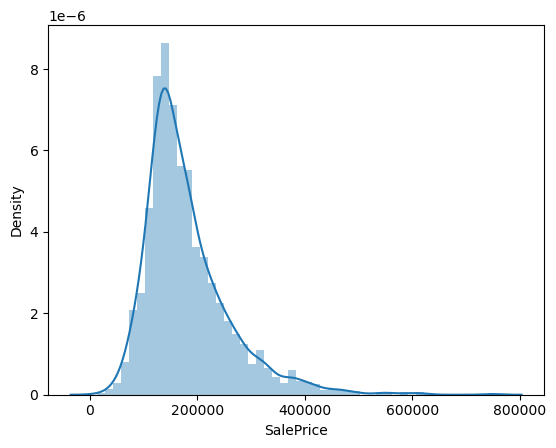

In [18]:
sns.distplot(df.SalePrice)

This shows that SalePrice does not follow normal distribution. It has positive skewness. It shows that very small number of houses have very high SalePrice. Also the SalePrice is not linear, which means we cannot find of a straight line that would fit through the SalePrice data. So we have to transform SalePrice so that it’ll have normal distribution.

Log transformation works fine with positive skewness

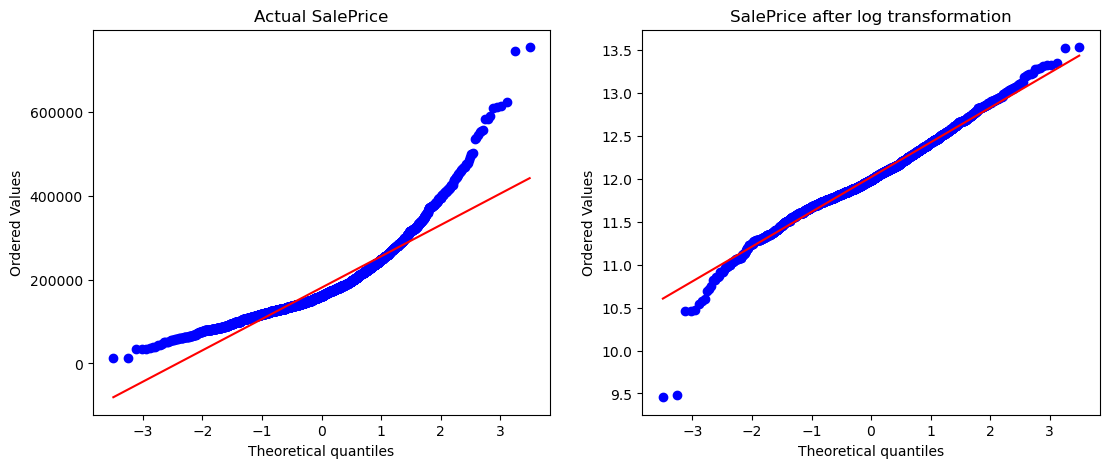

In [19]:
figure = plt.figure(figsize=(13, 5))
plt.subplot(1, 2, 1)
stats.probplot(df.SalePrice, plot=plt)
plt.title('Actual SalePrice')
plt.subplot(1, 2, 2)

df.SalePrice = np.log(df.SalePrice)

stats.probplot(df.SalePrice, plot=plt)
plt.title('SalePrice after log transformation')
plt.show()

### 3. Handling missing values

In [20]:
missing = df.isna().sum()
missing = missing[missing > 0]
missing_perc = missing / df.shape[0] * 100
na = pd.DataFrame([missing, missing_perc], index=['missing_num', 'missing_perc']).T
na = na.sort_values(by='missing_perc', ascending=False)
na

,missing_num,missing_perc
Pool QC,2917.0,99.556314
Misc Feature,2824.0,96.382253
Alley,2732.0,93.242321
Fence,2358.0,80.477816
Mas Vnr Type,1775.0,60.580205
Fireplace Qu,1422.0,48.532423
Lot Frontage,490.0,16.723549
Garage Cond,159.0,5.426621
Garage Qual,159.0,5.426621
Garage Finish,159.0,5.426621


In [21]:
df = df.drop(['PID', 'Order'], axis=1) 
df = df.drop(['Alley', 'Pool QC', 'Fence', 'Misc Feature'], axis=1) # drop columns with too many missing values
df = df.drop(['Mas Vnr Type', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cond', 'Garage Qual'], axis=1)
df = df.dropna(subset=['Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Electrical', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars', 'Garage Area'])
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())
df['Bsmt Qual'] = df['Bsmt Qual'].fillna(df['Bsmt Qual'].mode()[0])
df['Bsmt Cond'] = df['Bsmt Cond'].fillna(df['Bsmt Cond'].mode()[0])
df['Bsmt Exposure'] = df['Bsmt Exposure'].fillna(df['Bsmt Exposure'].mode()[0])
df['BsmtFin Type 1'] = df['BsmtFin Type 1'].fillna(df['BsmtFin Type 1'].mode()[0])
df['BsmtFin Type 2'] = df['BsmtFin Type 2'].fillna(df['BsmtFin Type 2'].mode()[0])

### 4. Understanding the correlations

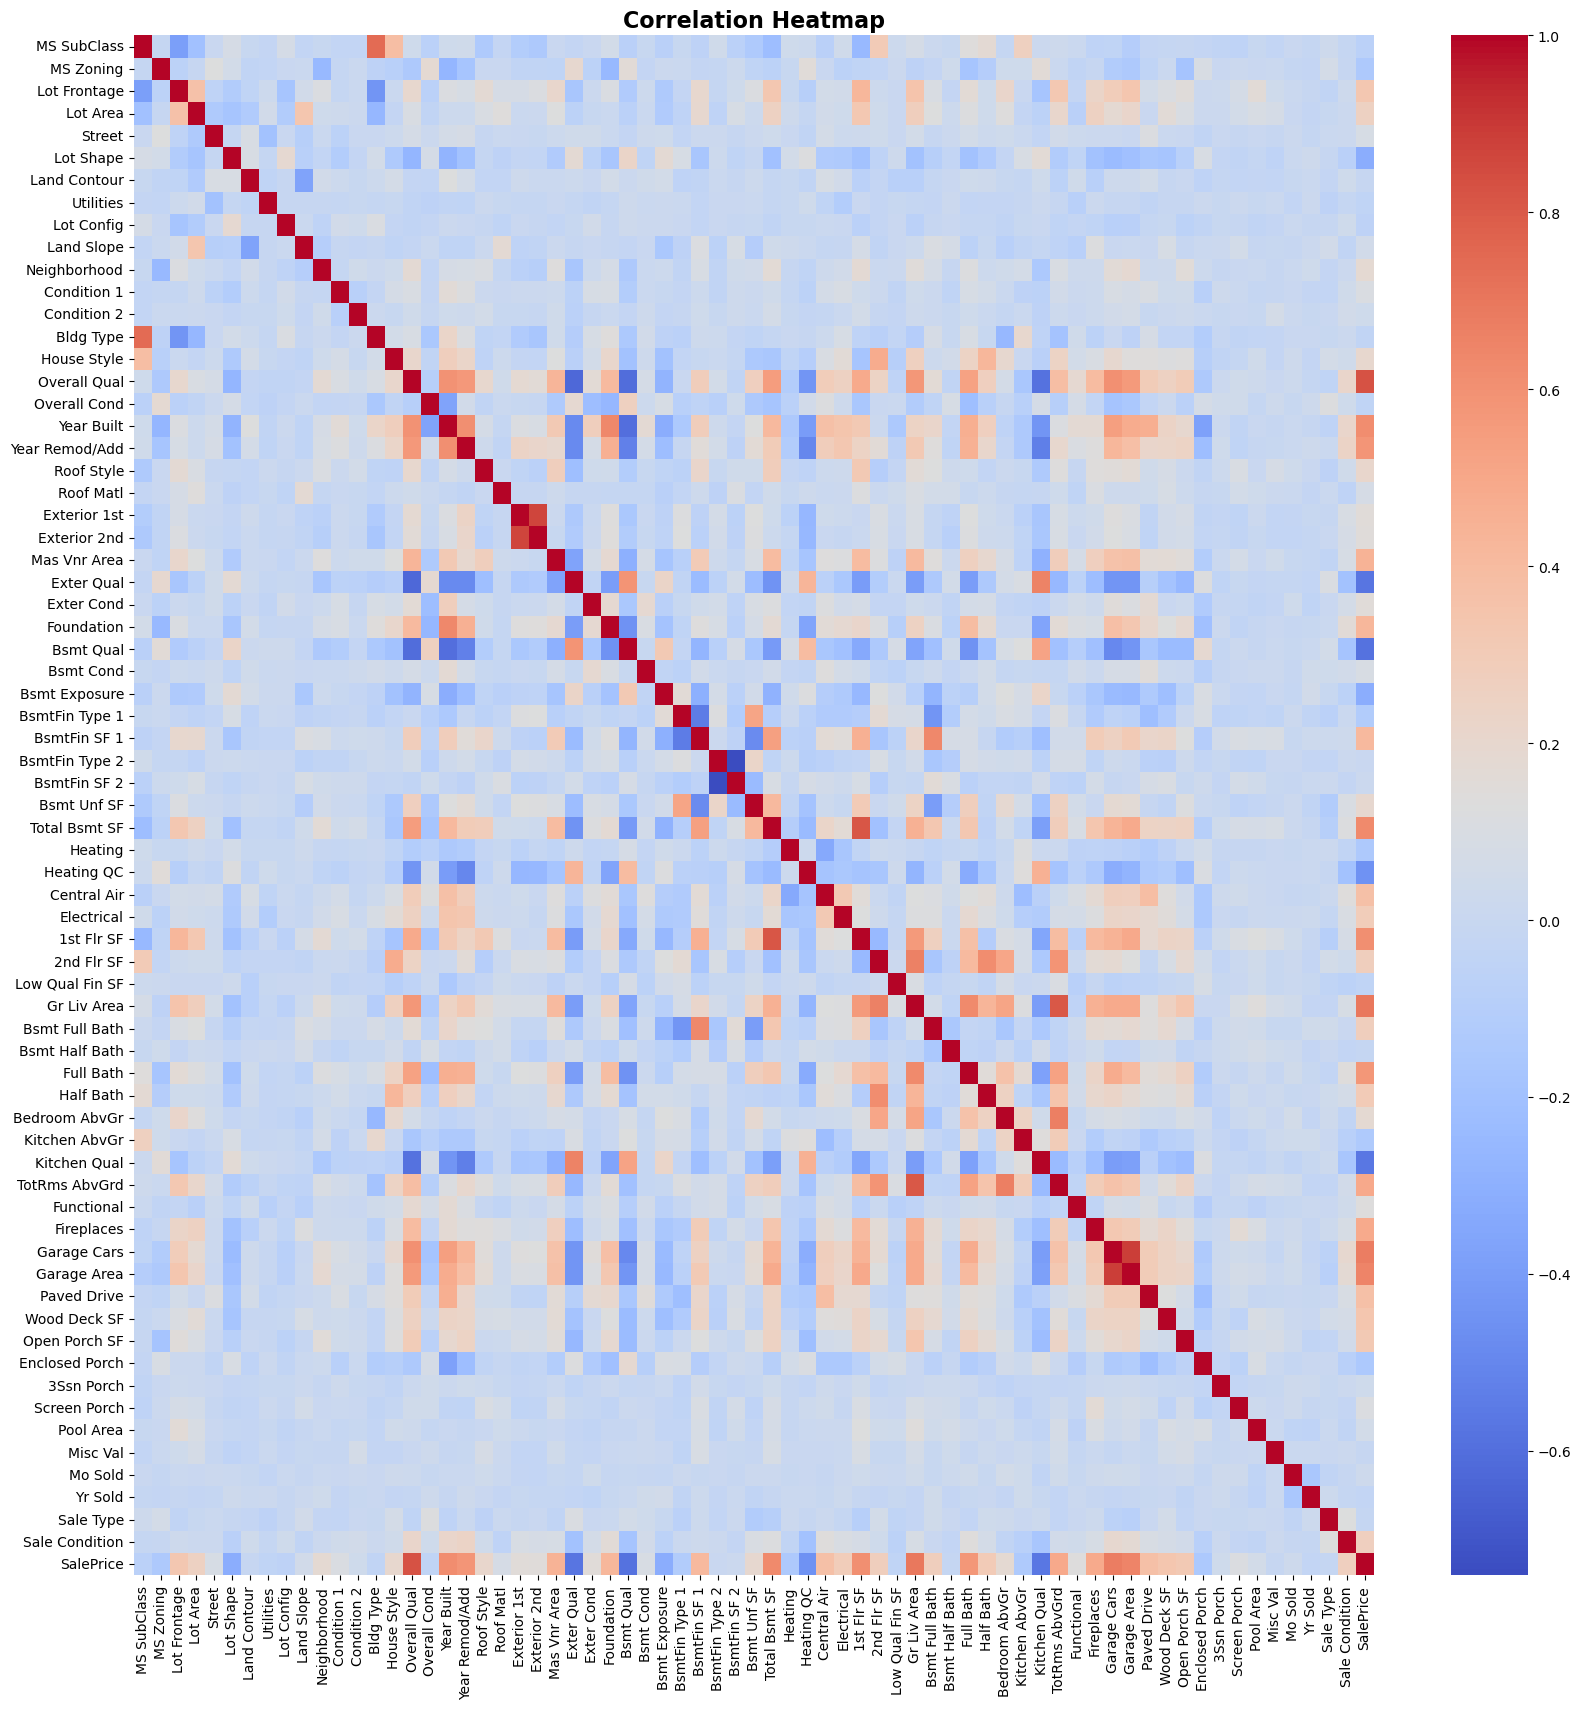

In [22]:
df_object = df.select_dtypes(include='object')
for i in df_object.columns:
    le = LabelEncoder()
    df[i] = le.fit_transform(df[i])
    
plt.figure(figsize=(20, 20))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap', weight='bold', fontsize=16)
plt.show()

So the heatmap shows that Overall quality and Ground Living Area have the highest correlation with the SalePrice. It is obvious because larger houses will definitely be costlier than smaller ones and though it is not clear on what basis OverallQual is calculated, SalePrice will be proportional to quality.

And other features with considerable correlations with SalePrice are TotalBsmtSF, 1stFlrSurface, FullBath, GarageCars and GarageArea, which also makes sense.

Also we can see some high correlation within the independent variables. There is high correlation between GrLivArea and TotRmsAbvGrd and similar relation exists between GarageCars and GarageArea. This will lead to multicollinearity and the our linear model may struggle to identify the relationship between these features and SalePrice. So it is recommended to drop one of those features.

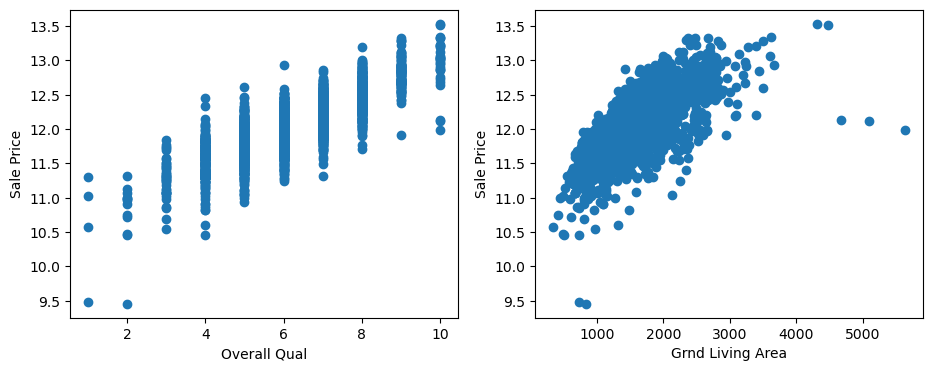

In [23]:
plt.figure(figsize = (11,4))
plt.subplot(1,2,1)
plt.scatter(df['Overall Qual'], df['SalePrice'])
plt.xlabel('Overall Qual')
plt.ylabel('Sale Price')
plt.subplot(1,2,2)
plt.scatter(df['Gr Liv Area'], df['SalePrice'])
plt.xlabel('Grnd Living Area')
plt.ylabel('Sale Price')
plt.show()

Deletion of outliers

In [24]:
df = df[df['Gr Liv Area'] < 4000]
df = df[df['SalePrice'] > 10]

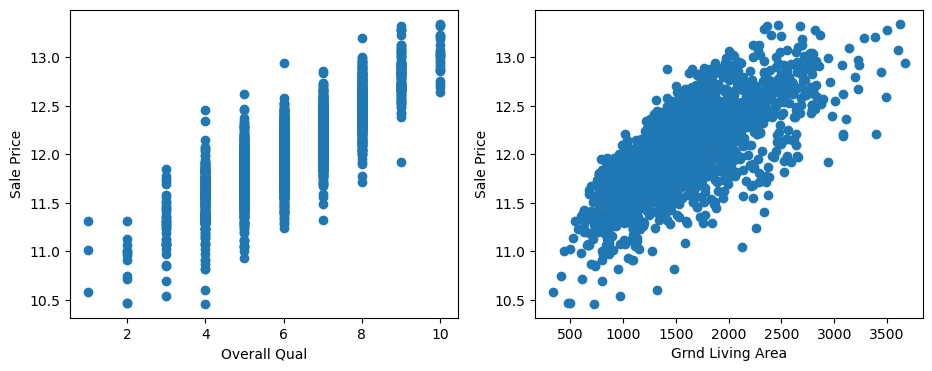

In [25]:
plt.figure(figsize = (11,4))
plt.subplot(1,2,1)
plt.scatter(df['Overall Qual'], df['SalePrice'])
plt.xlabel('Overall Qual')
plt.ylabel('Sale Price')
plt.subplot(1,2,2)
plt.scatter(df['Gr Liv Area'], df['SalePrice'])
plt.xlabel('Grnd Living Area')
plt.ylabel('Sale Price')
plt.show()

### 5. Feature Engineering

Having understood the correlations in the features, let’s do some feature engineering to make our data better for modelling.

So first let’s solve the multicollinearity issue. So i am going to drop the TotRmsAbvGrd, and GarageArea features as they have less correlation with the SalePrice compared to GarageCars and GrLivArea. 

In [26]:
df.drop(['TotRms AbvGrd', 'Garage Area'], axis=1, inplace=True)

Now we can think about adding new features to the dataset. As OverallQual, GrLivArea have high correlation with SalePrice, creating features that are just the higher powers of OverallQual and GrLivArea will help the model.

In [31]:
features = ['Overall Qual', 'Gr Liv Area']
for feat in features:
	df[feat + '_p2'] = df[feat] ** 2
	df[feat + '_p3'] = df[feat] ** 3 

### 5. Build the Model

In [34]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute missing values in X_train and X_test
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# we first try with alpha = 0.01 for ridge and lasso regressions
lm = LinearRegression()
ridge = Ridge(alpha=0.01)
lasso = Lasso(alpha=0.01)

# Fit to the training data
lm.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

Lasso(alpha=0.01)

Linear Regression

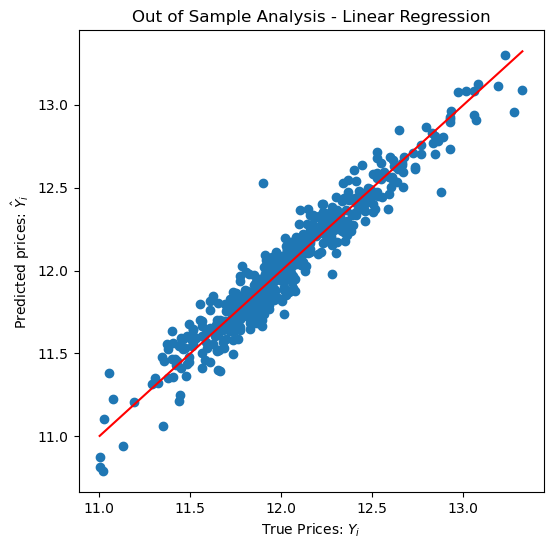

In [35]:
y_pred = lm.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel("True Prices: $Y_i$")
plt.ylabel("Predicted prices: $\hat{Y}_i$")
plt.title('Out of Sample Analysis - Linear Regression')
plt.show()

In [36]:
print('Linear Regression')
y_pred = lm.predict(X_test)
print('MSE: ', mean_squared_error(y_test, y_pred))
print('RMSE: ',np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2: ', r2_score(y_test, y_pred))

Linear Regression
MSE:  0.010144218320751746
RMSE:  0.1007185103183707
R2:  0.9277659159973043


Ridge Regression

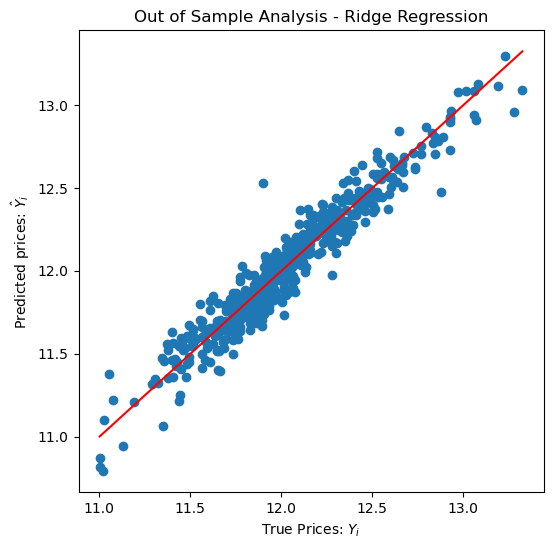

In [37]:
ridge_pred = ridge.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, ridge_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel("True Prices: $Y_i$")
plt.ylabel("Predicted prices: $\hat{Y}_i$")
plt.title('Out of Sample Analysis - Ridge Regression')
plt.show()

In [38]:
print("Ridge Regression:")
print("Mean Squared Error:", mean_squared_error(y_test, ridge_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2 Score:", r2_score(y_test, ridge_pred))

Ridge Regression:
Mean Squared Error: 0.010138588501657959
Root Mean Squared Error: 0.10069055815545944
R2 Score: 0.9278060043325985


Lasso Regression

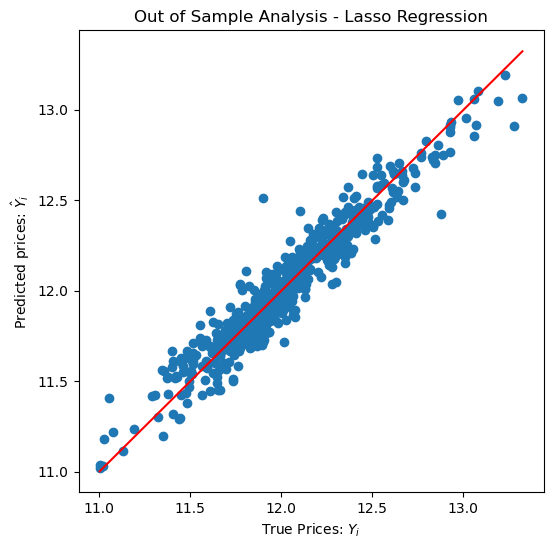

In [39]:
lasso_pred = lasso.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, lasso_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel("True Prices: $Y_i$")
plt.ylabel("Predicted prices: $\hat{Y}_i$")
plt.title('Out of Sample Analysis - Lasso Regression')
plt.show()

In [40]:
print("Lasso Regression:")
print("Mean Squared Error:", mean_squared_error(y_test, lasso_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R2 Score:", r2_score(y_test, lasso_pred))

Lasso Regression:
Mean Squared Error: 0.011213280037974383
Root Mean Squared Error: 0.10589277613687528
R2 Score: 0.9201534325664268


In [41]:
for alpha in np.arange(0, 0.01, 0.001):
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    lasso_pred = lasso.predict(X_test)
    print("\nLasso Regression with alpha =", alpha)
    print("Mean Squared Error:", mean_squared_error(y_test, lasso_pred))
    print("R2 Score:", r2_score(y_test, lasso_pred))


Lasso Regression with alpha = 0.0
Mean Squared Error: 0.010068090962101268
R2 Score: 0.9283079971952624

Lasso Regression with alpha = 0.001
Mean Squared Error: 0.010153784970839108
R2 Score: 0.9276977946118821

Lasso Regression with alpha = 0.002
Mean Squared Error: 0.010181197001906927
R2 Score: 0.9275026013606892

Lasso Regression with alpha = 0.003
Mean Squared Error: 0.010211257599604609
R2 Score: 0.9272885484222954

Lasso Regression with alpha = 0.004
Mean Squared Error: 0.010316347571605268
R2 Score: 0.9265402327191714

Lasso Regression with alpha = 0.005
Mean Squared Error: 0.010446432125637185
R2 Score: 0.9256139377296233

Lasso Regression with alpha = 0.006
Mean Squared Error: 0.01058477785951657
R2 Score: 0.9246288172357144

Lasso Regression with alpha = 0.007
Mean Squared Error: 0.010743514235446991
R2 Score: 0.9234985007982432

Lasso Regression with alpha = 0.008
Mean Squared Error: 0.010888235148612068
R2 Score: 0.9224679844718027

Lasso Regression with alpha = 0.0090000

In [ ]:
# Initialize Lasso regression model
lasso = Lasso(alpha=0.005)

# Use RFE to select top N features
selector = RFE(estimator=lasso, n_features_to_select=20)  # Specify the number of features
selector = selector.fit(X, y)

# Get selected features
important_features = df.drop('SalePrice', axis=1).columns[selector.support_].tolist()

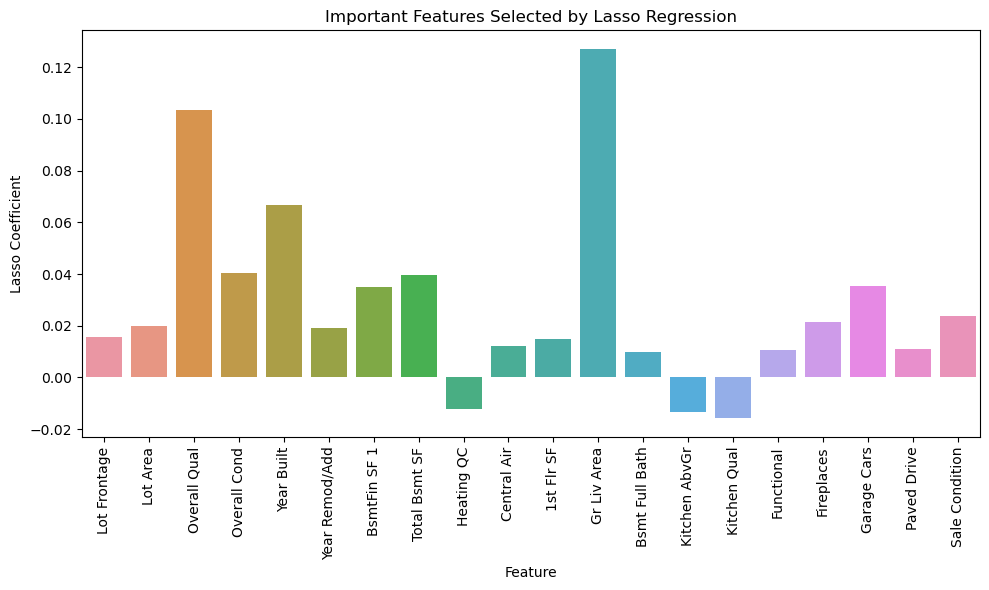

In [46]:
plt.figure(figsize=(10, 6))
sns.barplot(x=important_features, y=selector.estimator_.coef_)
plt.xticks(rotation=90)
plt.xlabel('Feature')
plt.ylabel('Lasso Coefficient')
plt.title('Important Features Selected by Lasso Regression')
plt.tight_layout()
plt.show()